Уважаемые коллеги. В данном файле я создавал данные и  заполнял таблицы в БД. В ходе написания скриптов возникло много нюансов. Поэтому данный ноутбук выстроен в хаотичном порядке, потому что я правил уже написанный код. Обещаю, что я учту свой опыт в написании следующих скриптов.

In [1]:
import glob
import re
import pandas as pd
import random
import numpy as np
from datetime import timedelta
import json
from sqlalchemy import create_engine
import pickle


In [ ]:
# Устанавливаю отсечку для повторяемости результатов
random.seed(6)

In [3]:
# Выбираем только нужные нам файлы
a=glob.glob(r'generated_files\\orders_2024_??.csv') 

In [4]:
# Готовим список к конкатенации
b=[pd.read_csv(i,sep=',') for i in a]

In [5]:
# Начальный df
df_start=pd.concat(b,ignore_index=True)

In [6]:
df_start.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72139 entries, 0 to 72138
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         72139 non-null  int64  
 1   order_date       72139 non-null  object 
 2   customer_name    72139 non-null  object 
 3   customer_phone   72139 non-null  object 
 4   product_id       72139 non-null  int64  
 5   product_name     72139 non-null  object 
 6   quantity         72139 non-null  int64  
 7   total_amount     72139 non-null  float64
 8   discount_amount  72139 non-null  float64
 9   status           72139 non-null  object 
 10  comment          72139 non-null  object 
 11  delivery_date    72139 non-null  object 
 12  gift_card        72139 non-null  int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 7.2+ MB


In [7]:
df_start.isna().sum()

order_id           0
order_date         0
customer_name      0
customer_phone     0
product_id         0
product_name       0
quantity           0
total_amount       0
discount_amount    0
status             0
comment            0
delivery_date      0
gift_card          0
dtype: int64

Обоснование:
В процессе анализа данных было выявлено, что файлы за первые три месяца (январь, февраль, март) содержат неполную структуру и большое количество пропусков. При этом их дубликаты с добавкой copy в имени файла имеют корректное и полное наполнение. Это может быть связано с особенностями настроек системы, ответственной за формирование исходных выгрузок.

Для обеспечения качества данных было принято решение:

переместить исходные «битые» файлы в отдельную папку для дальнейшего анализа или архивации;

переименовать «копии» файлов, удалив из имени пометку copy, чтобы они стали основными для загрузки и последующей обработки;

затем повторно собрать единый датафрейм из корректных файлов.

Данный подход позволит избежать ошибок при анализе, повысить качество данных и стандартизировать процесс загрузки.

Примечание:  Прошу обратить внимание на то, что данные уже приведены в соответствие, поэтому в вышеприведенной ячейке данные корректны.



In [2]:
#Начнем сначала
files=glob.glob(r'generated_files\orders_2024_??*.csv')

In [3]:
# Перезаписываем
files=[i.replace(' copy','') for i in files]

In [4]:
dfs=[pd.read_csv(i,sep=',') for i in files]

In [5]:
df_start1=pd.concat(dfs,ignore_index=True)

In [11]:
df_start1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72139 entries, 0 to 72138
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         72139 non-null  int64  
 1   order_date       72139 non-null  object 
 2   customer_name    72139 non-null  object 
 3   customer_phone   72139 non-null  object 
 4   product_id       72139 non-null  int64  
 5   product_name     72139 non-null  object 
 6   quantity         72139 non-null  int64  
 7   total_amount     72139 non-null  float64
 8   discount_amount  72139 non-null  float64
 9   status           72139 non-null  object 
 10  comment          72139 non-null  object 
 11  delivery_date    72139 non-null  object 
 12  gift_card        72139 non-null  int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 7.2+ MB


In [12]:
# Чистим пробелы по краям и я решил что формат будет таким Имя-Фамилия
df_start1['customer_name']=df_start1['customer_name'].str.strip().str.title()

In [13]:
# Приводим текстовые ячейки к красивому виду
df_start1['product_name']=df_start1['product_name'].str.strip().str.capitalize()
df_start1[['status','comment']]=df_start1[['status','comment']].apply( lambda x :x.str.strip().str.capitalize())

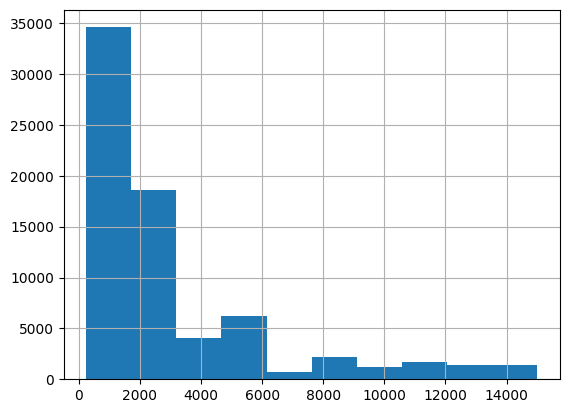

In [14]:
# Смотрим распределение общих сумм
df_start1['total_amount'].hist();

Вывод из histogramm: Основной юнит покупки лежит в пределах до 3000 условных единниц

In [15]:
# Oбрабатываем временные ячейки. Здесь первая обработка
df_start1['order_date1']=pd.to_datetime(df_start1['order_date'],errors='coerce')

In [16]:
# Дообрабатываем время
df_start1.loc[df_start1['order_date1'].isna(),'order_date1'] =pd.to_datetime(df_start1.loc[df_start1['order_date1'].isna(),'order_date'],format='mixed')

In [17]:
# Возвращаем структуру df
df_start1['order_date']=df_start1['order_date1']
df_start1=df_start1.drop(columns='order_date1')


In [18]:
# Обрабатываем даты в delivery_date, создав служебный столбец
df_start1['delivery_date1']=pd.to_datetime(df_start1['delivery_date'],errors='coerce')

In [19]:
# Есть необработанные значения и мы их дополнительно чистим
df_start1.loc[df_start1['delivery_date1'].isna(),'delivery_date1']=pd.to_datetime(df_start1['delivery_date'],format='mixed',errors='coerce')

In [20]:
# Проверка на пустые значения
df_start1['delivery_date1'].isna().sum()

np.int64(0)

In [21]:
# Приводим к исходной структуре с обработанными данными
df_start1['delivery_date']=df_start1['delivery_date1']
df_start1=df_start1.drop(columns='delivery_date1')

In [ ]:
# Создаем функцию для обработки телефоных номеров
def clean_formated_phone(string):
    if pd.isna(string):
        return None
    else:
        res=re.sub(r'\D','',string)
    if len(res)==9:# 9 потому что так сгенерировались номера. Номера фейковые
        phone=f'+7 ({res[1:5]}) {res[5:7]}-{res[7:]}'
    else: 
        return None
    return phone

In [23]:
df_start1['customer_phone']=df_start1['customer_phone'].apply(clean_formated_phone)

In [ ]:
# Поскольку данные очищены выведем сортированный df для последующего создания внешнего ключа
df_start1=df_start1.sort_values(by='order_date').reset_index(drop=True)

In [25]:
# Приготовим словарь для столбца с order_id_fk чтобы создать внешний ключ
maping={value:key for key,value in enumerate(list(dict.fromkeys(df_start1['order_id'])),start=1)}

In [26]:
df_start1['order_id_fk']=df_start1['order_id'].map(maping)

In [27]:
maping1={value:key for key,value in enumerate(list(dict.fromkeys(df_start1['customer_name'])),start=1)}

In [28]:
df_start1['customer_id_fk']=df_start1['customer_name'].map(maping1)

При генерации данных произошла избыточность количества карт.Сейчас чтобы сохранить логику и не возвращаться в начало буду генерировать подарочные карты. Сделаю 50 карт,симулировав выпуск и раздадим нашим клиентам в разном количестве от 1 до 3

In [29]:
def generation_cards(cnt):
    cards=set()
    while len(cards)<cnt:
        cards.add(''.join([str(random.randint(0,9)) for i in range(16)]))
    return cards


In [31]:
cards_lst=list(generation_cards(50))

In [32]:
clients_lst=df_start1['customer_name'].unique().tolist()

In [33]:
clients_lst

['Михаил Орлов',
 'Алексей Михайлов',
 'Ольга Кузнецова',
 'Сергей Сидоров',
 'Мария Петрова',
 'Анна Смирнова',
 'Дмитрий Кузнецов',
 'Елена Новикова',
 'Наталья Васильева',
 'Иван Иванов']

In [34]:
# Создаем  функцию симуляцию выдачи карт
def load_cards(clients_lst,cards_lst):
    client_cards={}
    for i in clients_lst:
        num =random.choices([1,2,3],[0.5,0.3,0.2],k=1)[0]
        client_cards[i]=[]
        for j in range(num):
            if cards_lst:
                client_cards[i].append(cards_lst.pop(0))
            else: break
    return client_cards

In [35]:
cards=load_cards(clients_lst,cards_lst)

In [ ]:
# Список неактивных карт сохраняю в json. Ниже закоментировал чать кода для невозможности срабатывания во время запуска ячейки
with open(r"Service files\Генерационные слайды\cards_lst_no_active.json", #"w", encoding="utf-8") as f:
    json.dump(cards_lst, f, ensure_ascii=False, indent=4)


Оказалось, я зря надеялся на seed. Это вообщем немного не стабильное решение.
Поэтому я  буду фиксировать данные в папку. 
Генерационные слайды, чтобы добиться однозначности. У меня пока на этой точке симуляция выданных и неактивных карт.

Словарь карт тоже надо зафиксировать.
С этого места будет объезд. Затем генерационные ячейки заглушу.

In [ ]:
#cards

In [ ]:
# Записываем клиентов с их картами. Я убрал 'w' что бы не сломалось
with open('Service files\Генерационные слайды/cards_copy.json',encoding='utf-8') as file:
    json.dump(cards,file,ensure_ascii=False,indent=4)
# Записали, глушим генерацию

In [75]:
# создаем функцию перекодировки карт
def maping(customer):
    return random.choice(cards[customer])

In [76]:
# Перекодируем
df_start1['gift_card']=df_start1['customer_name'].map(maping)

In [77]:
# Создадим внешний ключ 
maping2={value:key for key,value in enumerate(list(dict.fromkeys(df_start1['gift_card'])),start=1)}
df_start1['gift_card_id_fk']=df_start1['gift_card'].map(maping2)

Теперь я также сохраню df в csv файл

In [ ]:
#df_start1.to_csv('Service files\Генерационные слайды/df_start1.csv',index=False,encoding='utf-8')

Теперь я загружаю фиксированный df. Хотел не переименовывать его. Но решил несмотря на рутину все таки придерживаться правильных практик

In [6]:
df_start2=pd.read_csv(r'Service files\Генерационные слайды\df_start1.csv',parse_dates=['order_date','delivery_date'],dtype={'gift_card':'str'})

In [8]:
df_start2['product_name'].unique()

array(['Молоко', 'Подписка на газету', 'Корм для собак', 'Игрушка мяч',
       'Амуниция для собак'], dtype=object)

Сейчас сохраним список активных карт и произведем замену их в файле cards_data_all_active.csv

Нижеприведенные коды заглушим. Они отработали, но если запускать общий скрипт могут внести опять сумятицу

In [ ]:
#active_card=df_start2.sort_values(by='gift_card_id_fk')['gift_card'].unique().tolist()

In [ ]:
# Загружаем для замены файл с активными картами
#card_data_all_active=pd.read_csv(r'Service files\cards_data_all_active.csv')

In [ ]:
#card_data_all_active['card_number']=active_card

In [ ]:
#card_data_all_active=card_data_all_active.iloc[:,2:]

In [ ]:
#card_data_all_active.to_csv(r'Service files\cards_data_all_active.csv',index=False)

In [82]:
# Выделяем для загрузки только необходимые поля
df_orders=df_start2[['order_id', 'order_date',  'total_amount','discount_amount', 'status', 'comment', 'delivery_date',
        'customer_id_fk', 'gift_card_id_fk']]

In [83]:
# Order_id  имеют несколько позиций,поэтому группируем
df_orders=(
df_orders.groupby(['order_id', 'order_date', 'status', 'comment', 'delivery_date',
        'customer_id_fk', 'gift_card_id_fk'],sort=False).agg(totalsum=('total_amount','sum'),discountsum=('discount_amount','sum'))
        .reset_index()

)

In [84]:
df_orders=df_orders[['order_date','customer_id_fk', 'totalsum', 'discountsum','status', 'comment', 'delivery_date',
        'gift_card_id_fk','order_id' ]]
      

In [85]:
# Проверим логику дат
df_orders['order_date']<=df_orders['delivery_date']

0         True
1         True
2         True
3         True
4         True
         ...  
34663    False
34664    False
34665    False
34666    False
34667    False
Length: 34668, dtype: bool

In [86]:
# Исправим временой континиум
df_orders['delivery_date']=np.where((df_orders['order_date']<=df_orders['delivery_date']),df_orders['delivery_date'],(df_orders['order_date']+timedelta(days=3)))
df_orders['delivery_date']=df_orders['delivery_date'].dt.normalize()

In [87]:
df_orders.columns=['order_date', 'customer_id', 'total_amount', 'discount_amount', 'status',
       'comment', 'delivery_date', 'gift_card_id', 'order_code']

In [88]:
df_orders

,order_date,customer_id,total_amount,discount_amount,status,comment,delivery_date,gift_card_id,order_code
0,2024-01-01 00:15:00,1,5417.68,582.32,Processing,Нужно уточнить сроки,2024-01-24,1,2029636101335
1,2024-01-01 00:29:00,1,8406.38,593.62,Cancelled,Проверить наличие,2024-01-28,2,2029636930626
2,2024-01-01 00:29:00,1,1203.77,296.23,Cancelled,Проверить наличие,2024-01-28,1,2029636930626
3,2024-01-01 01:08:13,2,4745.03,654.97,Completed,Подарок вовремя,2024-01-09,3,2029635995788
4,2024-01-01 01:08:13,2,21840.40,2159.60,Completed,Подарок вовремя,2024-01-09,4,2029635995788
...,...,...,...,...,...,...,...,...,...
34663,2024-12-31 21:25:59,9,10376.52,423.48,Completed,Всё отлично!,2025-01-03,15,2030016863972
34664,2024-12-31 21:30:46,2,11379.13,2120.87,Completed,Проверить наличие,2025-01-03,4,2030017881270
34665,2024-12-31 21:30:46,2,2014.50,85.50,Completed,Проверить наличие,2025-01-03,3,2030017881270
34666,2024-12-31 22:14:51,8,2076.85,323.15,Completed,Проверить наличие,2025-01-03,13,2030017017848


In [9]:
with open (r'Service files\configDB.json','r', encoding='UTF-8') as file:
    data=json.load(file)

In [98]:
#Cоздадим параметры подключения
connect = f"postgresql+psycopg2://{data['user']}:{data['password']}@{data['host']}:{data['port']}/{data['db_base']}"

# Создаём движок
engine = create_engine(connect)

In [99]:
# Наткнулся на противоречие с ограничением по выбору заданных слов, поэтому прекодирую
df_orders['status']=np.where(df_orders['status']=='Processing','In Progress',df_orders['status'])

In [93]:
df_orders

,order_date,customer_id,total_amount,discount_amount,status,comment,delivery_date,gift_card_id,order_code
0,2024-01-01 00:15:00,1,5417.68,582.32,In Progress,Нужно уточнить сроки,2024-01-24,1,2029636101335
1,2024-01-01 00:29:00,1,8406.38,593.62,Cancelled,Проверить наличие,2024-01-28,2,2029636930626
2,2024-01-01 00:29:00,1,1203.77,296.23,Cancelled,Проверить наличие,2024-01-28,1,2029636930626
3,2024-01-01 01:08:13,2,4745.03,654.97,Completed,Подарок вовремя,2024-01-09,3,2029635995788
4,2024-01-01 01:08:13,2,21840.40,2159.60,Completed,Подарок вовремя,2024-01-09,4,2029635995788
...,...,...,...,...,...,...,...,...,...
34663,2024-12-31 21:25:59,9,10376.52,423.48,Completed,Всё отлично!,2025-01-03,15,2030016863972
34664,2024-12-31 21:30:46,2,11379.13,2120.87,Completed,Проверить наличие,2025-01-03,4,2030017881270
34665,2024-12-31 21:30:46,2,2014.50,85.50,Completed,Проверить наличие,2025-01-03,3,2030017881270
34666,2024-12-31 22:14:51,8,2076.85,323.15,Completed,Проверить наличие,2025-01-03,13,2030017017848


In [94]:
# Файл обработан и мы его сфотографируем
df_orders.to_pickle(r'Service files\Генерационные слайды\df_orders.plk')

Загрузка файлов встречает противодействие ограничений. Поэтому создам сначала родительские таблицы. Начнем с customers

In [90]:
df_customers=pd.read_csv(r'Service files\customers.csv',sep=',', encoding='UTF-8')

In [91]:
df_customers['registration_date']=pd.to_datetime(df_customers['registration_date'],errors='coerce')
df_customers=pd.merge(df_start1,df_customers,left_on='customer_name',right_on='name')

In [92]:
df_customers=(
    df_customers[['customer_id_fk','name', 'customer_phone',
         'email','registration_date', 'is_vip','loyalty_points']]
        .drop_duplicates(subset='name')
        .sort_values(by='customer_id_fk')
        .reset_index(drop=True)
        .drop(columns='customer_id_fk')
        .rename(columns={'customer_phone':'phone'})
        

)

И наконец пробуем загрузить

In [93]:
# Чтобы не вносить сумятицу в данные пока закоментируем код, поскольку он уже отработал. 
# хотя думаю что ограничение уникальности почты заблокирует действие
#df_customers.to_sql('customers',engine,schema=f"{data['schema']}", if_exists='append',index=False)
# Проверил: Ура,ограничение работает

Первая таблица залилась. Ура - я молодец.

Переходим к таблице карт. Логика такая, В таблице gift_card будут находится все карты. Все 50. Но у выданных будут атрибуты в виде  баланса даты выдачи и даты прекращения действия, а остальные будут как неактивированные и активироваться при выдаче.

In [52]:
df_active_card=(
    pd.read_csv(r'Service files\Генерационные слайды\cards_data_all_active.csv',sep=','
                ,dtype={'card_number': str},parse_dates=['activation_date','expiration_date'])
)


Обработаем таблицу активных карт

In [53]:
df_active_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   card_number      19 non-null     object        
 1   balance          19 non-null     int64         
 2   is_activated     19 non-null     bool          
 3   activation_date  19 non-null     datetime64[ns]
 4   expiration_date  19 non-null     datetime64[ns]
dtypes: bool(1), datetime64[ns](2), int64(1), object(1)
memory usage: 759.0+ bytes


In [55]:
df_cards=pd.merge(df_start2,df_active_card,left_on='gift_card',right_on='card_number')

In [57]:
# Надо обязательно все версии идущие в хронологии называт своими именами, иначе приходится бегать по коду
df_cards_sql=(
df_cards[['gift_card_id_fk', 'card_number',
       'balance', 'is_activated', 'activation_date', 'expiration_date']]
       .sort_values(by='gift_card_id_fk')
       .drop_duplicates()
       .rename(columns={'is_activated':'is_actived','activation_date':'actived_date','expiration_date':'expriration_date'})
       .reset_index(drop=True)
       .drop(columns='gift_card_id_fk')
       
)

Заливаем данные

In [77]:
df_cards_sql.to_sql('gift_cards',engine,schema='my_schema',if_exists='append',index=False)

19

Все получилось. И ограничение сработало

In [65]:
# для создания загрузочного df с неактивированными картами создадим функцию. Так мы автоматизируем ручной кодинг
def df_card_is_not_active(cards_lst,column_lst):
    cnt_rows=len(cards_lst)
    naming_lst=list(column_lst)
    dat={}
    dat[naming_lst[0]]=cards_lst
    dic={**dat,**{i:[pd.NA for i in  range(cnt_rows)] for i in naming_lst[1:]}}
    return pd.DataFrame(dic)

In [63]:
with open (r'Service files\Генерационные слайды\cards_lst_no_active.json','r',encoding='utf-8') as file:
    card_lst=json.load(file)

In [66]:
# Получили df для дозаливки в gift_cards
df_card_not_active  = df_card_is_not_active(cards_lst=card_lst,column_lst=df_cards_sql.columns)

In [ ]:
# Зафиксируем данные
#df_card_not_active.to_pickle(r'Service files\Генерационные слайды\card_no_active.pkl')

In [74]:
df_card_not_active1=pd.read_pickle(r'Service files\Генерационные слайды\card_no_active.pkl')

In [79]:
# Ну и заливаем
df_card_not_active1.to_sql('gift_cards',engine,schema='my_schema',if_exists='append',index=False)
# Получилось.Ограничение сработало. Можно попить чай.

IntegrityError: (psycopg2.errors.UniqueViolation) duplicate key value violates unique constraint "num_unik"
DETAIL:  Key (card_number)=(2893834242955493) already exists.

[SQL: INSERT INTO my_schema.gift_cards (card_number, balance, is_actived, actived_date, expriration_date) VALUES (%(card_number__0)s, %(balance__0)s, %(is_actived__0)s, %(actived_date__0)s, %(expriration_date__0)s), (%(card_number__1)s, %(balance__1)s, %(i ... 3053 characters truncated ... d_number__30)s, %(balance__30)s, %(is_actived__30)s, %(actived_date__30)s, %(expriration_date__30)s)]
[parameters: {'is_actived__0': None, 'actived_date__0': None, 'card_number__0': '2893834242955493', 'balance__0': None, 'expriration_date__0': None, 'is_actived__1': None, 'actived_date__1': None, 'card_number__1': '0111233837311989', 'balance__1': None, 'expriration_date__1': None, 'is_actived__2': None, 'actived_date__2': None, 'card_number__2': '9168247203021246', 'balance__2': None, 'expriration_date__2': None, 'is_actived__3': 

Настало время загрузки таблицы ордеров

In [95]:
df_orders_to_sql=pd.read_pickle(r'Service files\Генерационные слайды\df_orders.plk')

In [ ]:
# Заливаем.В SQL скрипте дабавил ограничение уникальности. Проверил - работает
df_orders_to_sql.to_sql('orders',engine,schema='my_schema',if_exists='append',index=False)

IntegrityError: (psycopg2.errors.UniqueViolation) duplicate key value violates unique constraint "unique_field1_field2"
DETAIL:  Key (gift_card_id, order_code)=(1, 2029636101335) already exists.

[SQL: INSERT INTO my_schema.orders (order_date, customer_id, total_amount, discount_amount, status, comment, delivery_date, gift_card_id, order_code) VALUES (%(order_date__0)s, %(customer_id__0)s, %(total_amount__0)s, %(discount_amount__0)s, %(status__0)s, ... 195809 characters truncated ... status__999)s, %(comment__999)s, %(delivery_date__999)s, %(gift_card_id__999)s, %(order_code__999)s)]
[parameters: {'total_amount__0': 5417.68, 'discount_amount__0': 582.32, 'gift_card_id__0': 1, 'comment__0': 'Нужно уточнить сроки', 'order_code__0': 2029636101335, 'status__0': 'In Progress', 'delivery_date__0': datetime.datetime(2024, 1, 24, 0, 0), 'customer_id__0': 1, 'order_date__0': datetime.datetime(2024, 1, 1, 0, 15), 'total_amount__1': 8406.380000000001, 'discount_amount__1': 593.62, 'gift_card_id__